# Image processing notebook: From overlap corrected to transmission 

### 00 - exp 204

exp202: no lines batch03 (3C)

exp203: no lines batch03 (-3C)

exp204: sample 4/5 at position 13 (several temperatures)

exp205: batch03 for sample 4/5 pos 13 (exp204). batch05 for sample 7/8 at position 52 (exp202, exp203)

##  Initial settings

### Import libraries
Import all the required libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select Directories Reference Imgs
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_JL_BOA\00_Processed\01_Overlap_corrected\exp205"

In [3]:
# %load select_directory('ref_dst_dir')
ref_dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_JL_BOA\00_Processed\02_Transmission_results\00_testings\exp205_crop01"

### Select Directories Experiment 
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [4]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_JL_BOA\00_Processed\01_Overlap_corrected\exp202"

In [5]:
# %load select_directory('exp_dst_dir')
exp_dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_JL_BOA\00_Processed\02_Transmission_results\00_testings\exp202_crop01"

### Check reference folders to process

In [6]:
ref_dict = prep_stack_dict(ref_dir)
for key in ref_dict.keys():
    print(key)

000_temp_00_m3_ob
001_temp_00_m3_batch01
002_temp_00_m3_batch02
003_temp_00_m3_batch03
004_temp_00_m3_batch04
005_temp_00_m3_batch05
006_ob_99


In [7]:
exp_dict = prep_stack_dict(src_dir)
for key in exp_dict.keys():
    print(key)

000_temp_00_m3_ob
001_temp_00_m3_batch01
002_temp_00_m3_batch02
003_temp_00_m3_batch03


In [ ]:
ref_folder = ['005_temp_00_m3_batch05']
proc_folder = ['003_temp_00_m3_batch03']

### Testing cropping

## Testing mode

In [8]:
exp_folder = ['003_temp_00_m3_batch03']
ref_folder = ['005_temp_00_m3_batch05']
exp_test_dict, exp_test_param = testing_mode_step (src_dir, proc_folder = exp_folder, keep_acq_numb= 5)
ref_test_dict, ref_test_param = testing_mode_step (ref_dir, proc_folder = ref_folder, keep_acq_numb= 5)

Reading Images: 100%|████████████████████████████| 3/3 [00:13<00:00,  4.60s/it]


In [9]:
pre_proc_seq = [stack_averaging]

In [10]:
add_to_dict(exp_test_param,['threshold', 'roi_crop', 'frames_binning_factor'], [0, [0, 252, 512, 256], 5])
add_to_dict(ref_test_param,['threshold', 'roi_crop', 'frames_binning_factor'], [0, [0, 252, 512, 256], 5])

In [11]:
exp_test_dict = pre_processing_step (exp_test_dict, pre_proc_seq, param_dict = exp_test_param)
ref_test_dict = pre_processing_step (ref_test_dict, pre_proc_seq, param_dict = ref_test_param)

In [12]:
proc_seq_ref = [scrubbing_correction_dict]
proc_seq_exp = [scrubbing_correction_dict]

In [13]:
exp_test_dict = processing_step (exp_test_dict, proc_seq = proc_seq_exp, param_dict = exp_test_param)
ref_test_dict = processing_step (ref_test_dict, proc_seq = proc_seq_ref, param_dict = ref_test_param)

Processing Scrubbing Correction: 100%|███████████| 1/1 [00:00<00:00,  2.44it/s]


In [14]:
pre_proc_seq = [crop_img, binning_frames, outlier_removal]

In [15]:
exp_test_dict = pre_processing_step (exp_test_dict, pre_proc_seq, param_dict = exp_test_param)
ref_test_dict = pre_processing_step (ref_test_dict, pre_proc_seq, param_dict = ref_test_param)

Processing Filetring : 100%|█████████████████████| 1/1 [00:00<00:00, 32.92it/s]


In [ ]:
#proc_seq_ref = [SBKG_correction_dict]
#proc_seq_exp = [SBKG_correction_dict, image_registration_dict]
proc_seq_exp = [image_registration_dict]

In [ ]:
#BB_mask = get_img(ref_dir + '/mask_img_crop3.fits')
#add_to_dict(ref_test_param,['BB_mask'], [BB_mask])
#ref_test_dict = processing_step (ref_test_dict, proc_seq = proc_seq_ref, param_dict = ref_test_param)

In [ ]:
x= float(-0.5)
y = float(-1.08888889)
M = np.array([[1,0,x], [0,1,y], [0,0,1]])
BB_mask = get_img(src_dir + '/mask_img_crop3.fits')
add_to_dict(exp_test_param,['BB_mask', 'M', 'ref_dict', 'nca'], [BB_mask, M, ref_test_dict, [440, 19, 28, 152]])

In [ ]:
exp_test_dict = processing_step (exp_test_dict, proc_seq = proc_seq_exp, param_dict = exp_test_param)

In [ ]:
saving_step (exp_test_dict, exp_dst_dir, img_name = 'testING_M4')

In [ ]:
saving_step (ref_test_dict, ref_dst_dir, img_name = 'testING_REF')

In [ ]:
exp_test_dict = pre_processing_step (exp_test_dict, pre_proc_seq, param_dict = exp_test_param)
ref_test_dict = pre_processing_step (ref_test_dict, pre_proc_seq, param_dict = ref_test_param)

In [16]:
ref_img = avg_frames_dict (ref_test_dict[ref_folder[0]], output_type = 'img')
exp_img = avg_frames_dict (exp_test_dict[exp_folder[0]], output_type = 'img')

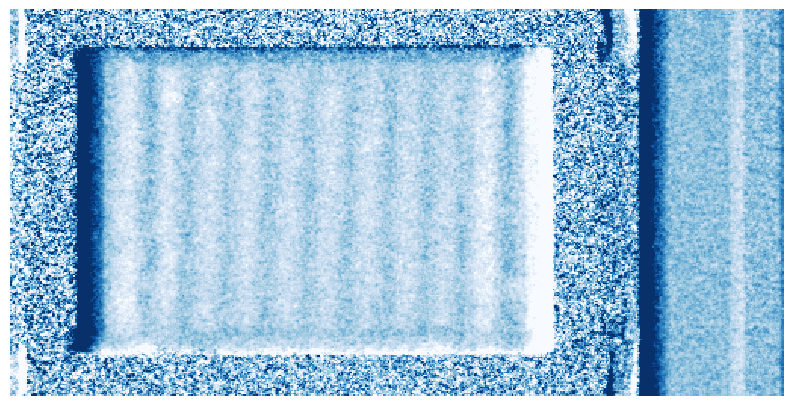

In [17]:
fin_img = np.nan_to_num((exp_img[0]/ref_img[0]) , posinf=255, neginf=255)
show_img(fin_img, cmap='Blues')

## Image Registration
Displacement correction

In [18]:
#ref_folder = ['003_temp_00_m3_batch03']
#exp_folder = ['007_temp_03_m10_batch01']

#ref_dict, _ = testing_mode_step (ref_dir, proc_folder = ref_folder, keep_acq_numb = 1)
#exp_dict, _ = testing_mode_step (src_dir, proc_folder = exp_folder, keep_acq_numb = 1)

In [19]:
#ref_img = avg_frames_dict (ref_dict[ref_folder[0]], output_type = 'img')
#exp_img = avg_frames_dict (exp_dict[exp_folder[0]], output_type = 'img')

### Images without correction

In [20]:
#fin_img = np.nan_to_num((exp_img[0]/ref_img[0]) , posinf=255, neginf=255)
#show_img(fin_img, cmap='Blues')

### Correcting the displacement

In [151]:
reg_rois_list = [([335, 16, 175, 50], 'h'), ([333, 190, 175, 50], 'h'), ([25, 16, 47, 225], 'v'), 
                 ([450, 19, 30, 202], 'v'), ([80, 200, 250, 20], 'v'), ([38, 30, 328, 20], 'v'), 
                ([340, 16, 47, 225], 'v')]

In [182]:
reg_rois_list = [([25, 16, 47, 225], 'v,h'), ([400, 19, 100, 210], 'h'), 
                 ([340, 16, 47, 225], 'v,h')]

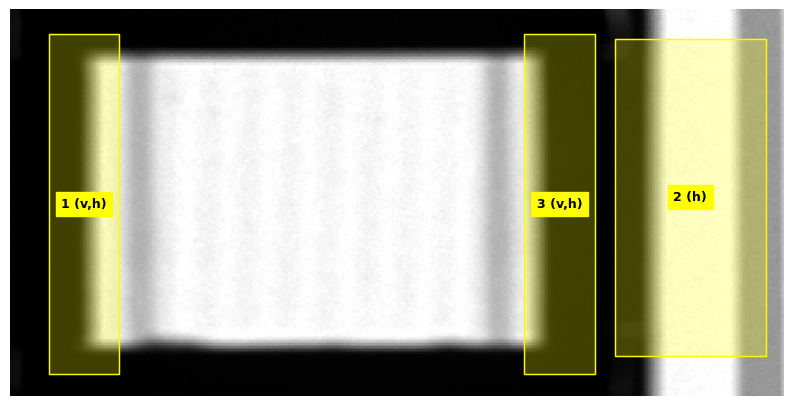

In [183]:
show_img_rois(exp_img[0], dr = [(reg_rois_list, 'yellow')])

In [184]:
#List for full image
#reg_rois_list = [([408, 280, 88, 192], 'v,h'), ([320, 263, 43, 228], 'v,h'), ([30, 262, 55, 228], 'v,h'), 
#                 ([313, 264, 155, 46], 'v,h'), ([313, 433, 176, 46], 'v,h')]
#show_img_rois(exp_img[0], dr = [(reg_rois_list, 'yellow')])

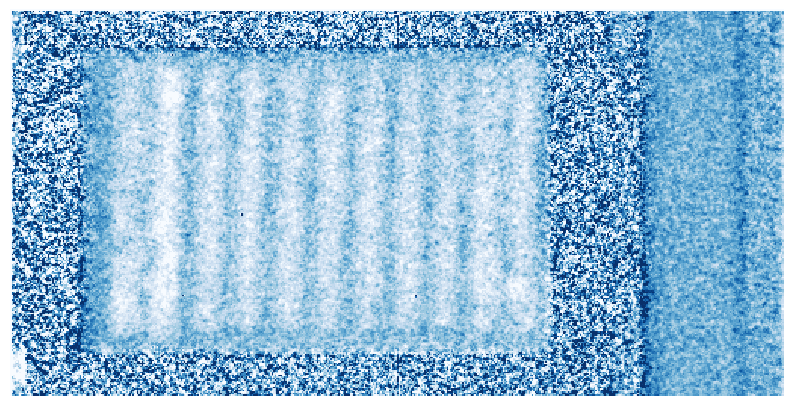

[[ 1.          0.         -0.13333333]
 [ 0.          1.         -0.91111111]
 [ 0.          0.          1.        ]]


In [185]:
#reg_img = get_img(os.path.dirname(src_dir) + '/reg_img.fits')
img_reg_corr, M = img_registration (exp_img, ref_img, reg_rois_list = reg_rois_list, dof=['tx', 'ty'])

fin_img = np.nan_to_num((img_reg_corr[0]/ref_img[0]) , posinf=255, neginf=255)
show_img(fin_img, cmap = 'Blues')
print(M)

## Gettinging an NCA

In [ ]:
# %load select_rois(img_reg_corr[0], list_rois = ['nca'])
nca = [440, 25, 32, 210]
#440, 278, 33, 215

In [ ]:
show_img(img_reg_corr[0], dr = [(nca, 'blue')], cmap='gray')

## Process the reference folder (if not done before)
Or in case it is not previously saved.

In case the parameters and ref_dict are stored in the global variables, you can load them with : `%store -r "name given"`

It is **important** to not process the images fully before having played with them to find the right parameters (there is a notebook called playgound todo this)

In [ ]:
#%store -r exp_param
#ref_dir =  r"J:\700 Campaigns - internal\2022\PSI22_JL_BOA\00_Processed\02_Transmission_results\exp205_cropped_noSBKG"
#ref_dict = read_saved_dict (ref_dir, proc_folder = [])

### Continue here if ref images are not done
if the ref images were done (with the same processing intended) then continue to section 3

In [ ]:
ref_param = {}

add_to_dict(ref_param, ['threshold', 'roi_crop', 'frames_binning_factor'], [0, [0, 241, 512, 261], 5])

In [ ]:
ref_seq =  [stack_averaging,
            crop_img,
            binning_frames,
            scrubbing_correction_dict,
            outlier_removal
            #SBKG_correction_dict
           ]

In [ ]:
proc_folder = ref_folder

BB_mask = get_img(ref_dir + '/mask_img_crop.fits')
add_to_dict(ref_param,['BB_mask'], [BB_mask])

ref_dict = full_processing (ref_dir, ref_dst_dir, proc_folder = proc_folder, sequence = ref_seq, 
                 proc_parameters = ref_param, img_name = 'ref_intensity_B03', save = True)

## Base parameters and Sequence for Experiment

In [ ]:
exp_param = {}

add_to_dict(exp_param, ['threshold', 'use_ref', 'ref_dict', 'nca', 'roi_crop', 'frames_binning_factor'], [0, False, ref_dict, nca, [0, 241, 512, 261], 5])

In [ ]:
exp_seq =  [stack_averaging,
            crop_img,
            binning_frames,
            scrubbing_correction_dict,
            outlier_removal,
            #SBKG_correction_dict,
            image_registration_dict,
            intensity_correction_dict]
            #referencing_dict]

### Processing Batch 01

In [ ]:
proc_folder = ['001_temp_00_m4_batch01']

x= float(-0.5)
y = float(-1.08888889)
M = np.array([[1,0,x], [0,1,y], [0,0,1]])
BB_mask = get_img(src_dir + '/mask_img_crop.fits')
add_to_dict(exp_param,['BB_mask', 'M'], [BB_mask, M])

exp_dict = full_processing (src_dir, exp_dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

In [ ]:
proc_folder = ['003_temp_01_m6_batch01']

x= float(-0.43333333)
y = float(-1.04444444)
M = np.array([[1,0,x], [0,1,y], [0,0,1]])
BB_mask = get_img(src_dir + '/mask_img_crop.fits')
add_to_dict(exp_param,['BB_mask', 'M'], [BB_mask, M])

exp_dict = full_processing (src_dir, exp_dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

In [ ]:
proc_folder = ['005_temp_02_m8_batch01']

x= float(-0.46666667)
y = float(-1.04444444)
M = np.array([[1,0,x], [0,1,y], [0,0,1]])
BB_mask = get_img(src_dir + '/mask_img_crop.fits')
add_to_dict(exp_param,['BB_mask', 'M'], [BB_mask, M])

exp_dict = full_processing (src_dir, exp_dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

In [ ]:
proc_folder = ['007_temp_03_m10_batch01']

x= float(-0.75)
y = float(-1.02222222)
M = np.array([[1,0,x], [0,1,y], [0,0,1]])
BB_mask = get_img(src_dir + '/mask_img_crop.fits')
add_to_dict(exp_param,['BB_mask', 'M'], [BB_mask, M])

exp_dict = full_processing (src_dir, exp_dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)